# Accenture future of skills questionnaire

In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from numpy.linalg import norm

First, load the questionnaire data and the lists of the tasks and abilities contained in the questionnaire.

There are two datasets: companies (where participants recruited directly from businesses) and online (participants recruited using Prolific), which we will tag and merge.

In [2]:
company_df = pd.read_csv("Future_of_skills_companies_20250910.csv")
online_df = pd.read_csv("Future_of_skills_online_20251023.csv")
online_df = online_df.drop('prescreen', axis=1)
company_df["source"] = "companies"
online_df["source"] = "online"
df = pd.concat([company_df, online_df])
# df = online_df.copy()
# df = company_df.copy()

tasks = pd.read_csv("tasks.csv")
abilities = pd.read_csv("abilities.csv")
domains = pd.read_csv("domains.csv")

Then let's do some quality control.

We'll set a threshold for how much of the questionnaire was completed (% completed) and  their performance (% correct) on the cognitive abilities familiarisation quiz (Question 4).

In [3]:
completion_threshold = 80
quiz_threshold = 75

print(f'Initial participants: {len(df)}')
df = df[df["Progress"] >= completion_threshold].reset_index(drop=True)
quiz_cols = ["Q4.12","Q4.13","Q4.14","Q4.25","Q4.26","Q4.27"]
df["quiz_score"] = (df[quiz_cols] == 1.0).sum(axis=1) / 6 * 100
df = df[df["quiz_score"] >= quiz_threshold].reset_index(drop=True)
unique_ids = np.unique(df["ResponseId"])
print(f'Participants remaining: {len(unique_ids)}')

Initial participants: 280
Participants remaining: 150


Question 2 covers general participant information (their job, experience, education, demographic information and positivity about AI).

In [85]:
domains

,Number,Type,Sub-types,Acronym
0,1,Manual-physical,Warehouse or logistics,WL
1,2,Manual-physical,"Manufacture, maintenance, or repair",MMR
2,3,Computer-digital,"Numerical, data, or programming",NDP
3,4,Computer-office,"Admin, organisational, or planning",AOP
4,5,Computer-office,"Customer service, marketing or HR",CMH
5,6,Face-to-face,"Hospitality, sales, or client care",HSC


In [4]:
domain_counts = df["Q2.11"].value_counts().sort_index()
print(f'Number of participants in each domain: {domain_counts}')

Number of participants in each domain: Q2.11
1.0    11
2.0     9
3.0    23
4.0    48
5.0    33
6.0    26
Name: count, dtype: int64


We can then look at distributions of age (Q2.7), sex (Q2.8), education (Q2.9 and Q2.10) and job experience (Q2.4 and Q2.5). Question 2 also asked participants about how positive they felt about AI in their field (Q2.6).

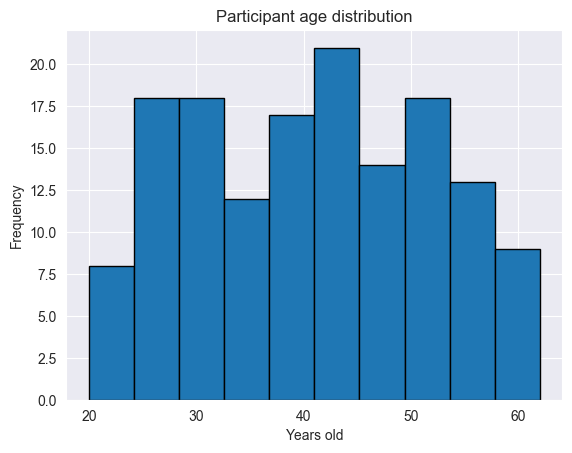

In [5]:
# age
df["age"] = 2025 - pd.to_numeric(df["Q2.7"], errors="coerce")
df["age"].hist(bins=10, edgecolor="black")
plt.title("Participant age distribution")
plt.xlabel("Years old")
plt.ylabel("Frequency")
plt.show()

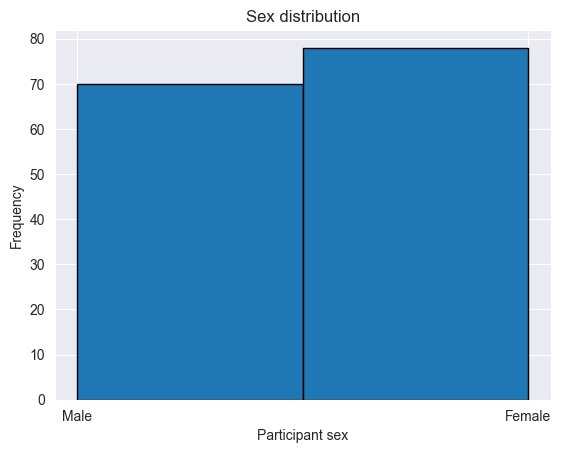

In [6]:
# sex
df["Q2.8"].hist(bins=2, edgecolor="black")
plt.title("Sex distribution")
plt.xlabel("Participant sex")
plt.ylabel("Frequency")
plt.xticks([1, 2], ["Male", "Female"])
plt.show()

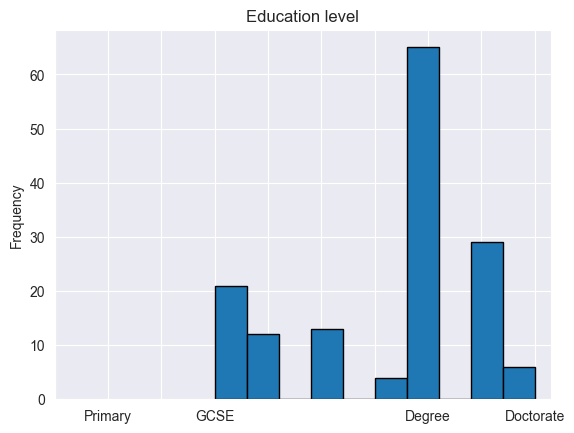

In [7]:
# education
df["Q2.9"].hist(bins=10, edgecolor="black")
plt.title("Education level")
plt.ylabel("Frequency")
plt.xticks([1,2,3,4,5,6,7,8,9,10],
           ["", "Primary", "", "GCSE", "", "", "", "Degree", "", "Doctorate"])
plt.show()

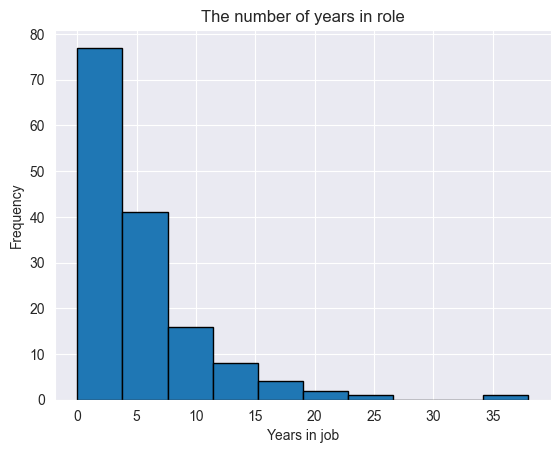

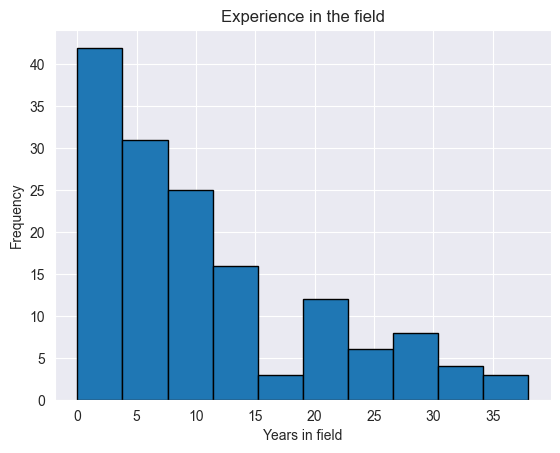

In [8]:
# job experience
df["Q2.4"].hist(bins=10, edgecolor="black")
plt.title("The number of years in role")
plt.xlabel("Years in job")
plt.ylabel("Frequency")
plt.show()

df["Q2.5"].hist(bins=10, edgecolor="black")
plt.title("Experience in the field")
plt.xlabel("Years in field")
plt.ylabel("Frequency")
plt.show()

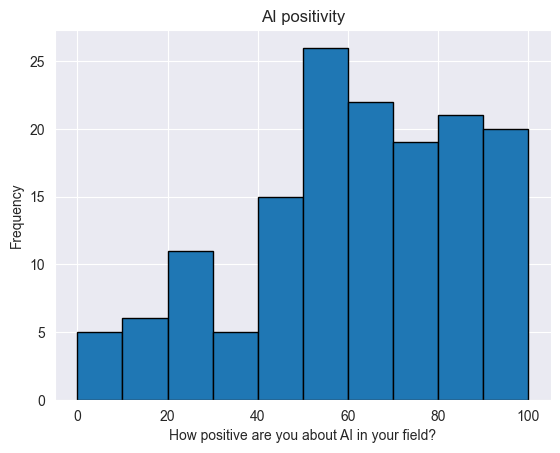

In [9]:
# AI positivity
df["Q2.6_1"].hist(bins=10, edgecolor="black")
plt.title("AI positivity")
plt.ylabel("Frequency")
plt.xlabel("How positive are you about AI in your field?")
plt.show()

Question 3 covers the job tasks that participants perform as part of their role.

In [10]:
tasks

,Number,Task,Example,Heading
0,1,Finding out information,"learning about latest developments, researchin...",Researching
1,2,Checking quality,"inspecting products or documents, interviewing...",Checking
2,3,Making decisions,"deciding project goals, choosing between diffe...",Decision making
3,4,Solving problems,"finding ways to overcome roadblocks, fix issue...",Problem solving
4,5,Thinking creatively,coming up with new ideas for products or marke...,Creative thinking
5,6,Long-term planning,"considering the overall goals for a project, s...",LT planning
6,7,Short-term planning,"scheduling your time, deciding which tasks are...",ST planning
7,8,Working with tools or materials,"using physical tools or machines, using your h...",Tool use
8,9,Using computer software,"interacting with computer software, email or a...",Computer use
9,10,Writing code,creating programmes or interacting with a comp...,Coding


At this point we will select whether we want to focus on a single domain, or look at the all domains combined.

In [11]:
selected_domain = 0 # 1-6, 0 for all domains

And we'll create some useful domain dictionaries

In [12]:
num2domain_acronym = dict(zip(domains["Number"],domains["Acronym"]))
num2domain_subtype = dict(zip(domains["Number"],domains["Sub-types"]))
num2domain_acronym[0] = "all domains"
num2domain_subtype[0] = "1-6"

print(f"Selected domain: {str(selected_domain)}: {num2domain_acronym[selected_domain]} ({num2domain_subtype[selected_domain]})")

Selected domain: 0: all domains (1-6)


To understand which tasks are important within different domains, we'll compute a weighted summary score of the task ranks (Q3.2).

In [13]:
def select_task_data(question):
    df_tasks = df.copy()
    df_tasks = df_tasks.loc[:, df.columns.str.contains(question)]
    df_tasks = df_tasks.iloc[:,:18]
    headings = tasks["Heading"].tolist()
    df_tasks.columns = headings
    df_tasks["domain"] = df["Q2.11"]
    df_tasks = df_tasks.reset_index().melt(id_vars=["index","domain"], var_name="task", value_name="value").dropna()
    df_tasks.rename(columns={"index":"participant"}, inplace=True)
    df_tasks["value"] = df_tasks["value"].astype(int)
    return df_tasks

def create_task_summary(df, summary_groups):
    task_summary = (
        df
        .groupby(summary_groups)
        .agg(
            mean_values=("value","mean"),
            count=("value","count"),
            total_points=("points","sum")
        )
        .reset_index()
    )
    task_summary["weighted_score"] = task_summary["total_points"] / task_summary["count"]
    return task_summary

# create the task summary
question = "Q3.2"
df_tasks = select_task_data(question)
df_tasks["points"] = 6 - df_tasks["value"]
task_summary = create_task_summary(df_tasks,["domain","task"])
task_summary

,domain,task,mean_values,count,total_points,weighted_score
0,1.0,Admin,5.000000,2,2,1.000000
1,1.0,Analysing data,2.000000,1,4,4.000000
2,1.0,Building rapport,4.666667,3,4,1.333333
3,1.0,Checking,2.000000,7,28,4.000000
4,1.0,Communicating,3.000000,3,9,3.000000
...,...,...,...,...,...,...
98,6.0,Managing resources,3.666667,3,7,2.333333
99,6.0,Problem solving,3.071429,14,41,2.928571
100,6.0,Researching,2.714286,7,23,3.285714
101,6.0,ST planning,3.444444,9,23,2.555556


Let's plot the task importance:

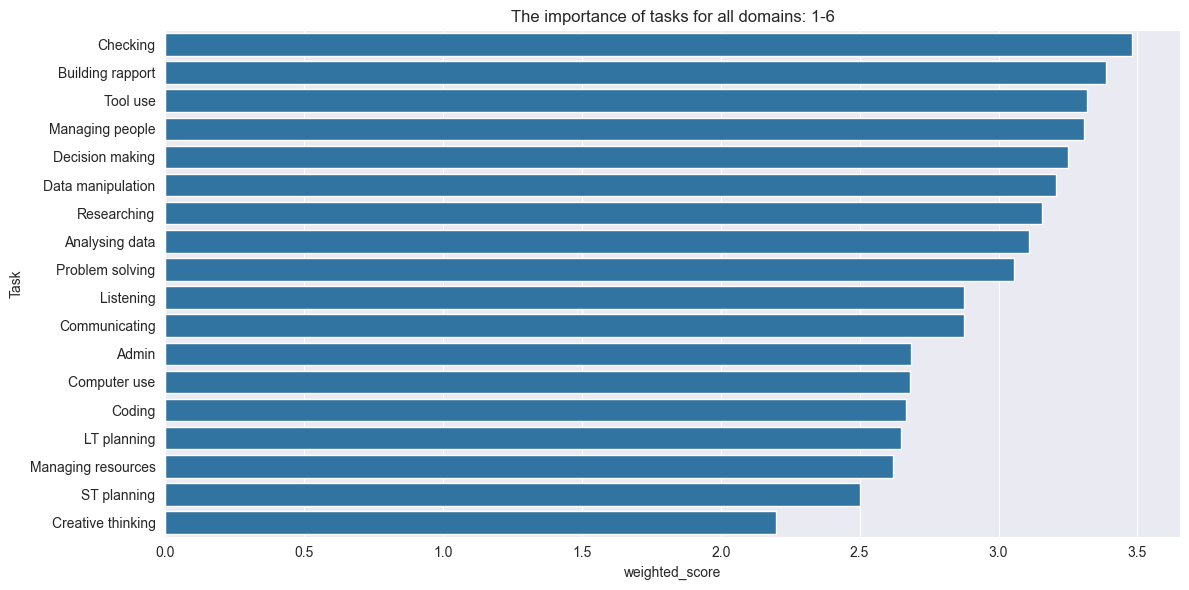

In [14]:
def plot_barplot(selected_domain,title,value_label="weighted_score"):
    summary_groups = ["task","domain"]
    if selected_domain == 0:
        summary_groups = ["task"]
    plot_data = create_task_summary(df_tasks,summary_groups)
    if selected_domain > 0:
        plot_data = plot_data[plot_data["domain"] == selected_domain]
        plot_data = plot_data.drop("domain", axis=1)
    plot_data = plot_data.sort_values(value_label, ascending=False)
    plt.figure(figsize=(12,6))
    sns.barplot(
        data=plot_data,
        x=value_label, y="task",
        dodge=True)
    plt.title(title)
    plt.xlabel(value_label)
    plt.ylabel("Task")
    plt.tight_layout()
    plt.show()

# choose domain
title = f"The importance of tasks for {num2domain_acronym[selected_domain]}: {num2domain_subtype[selected_domain]}"
plot_barplot(selected_domain, title)

And we can plot a heatmap to visualise the importance of tasks across domains.

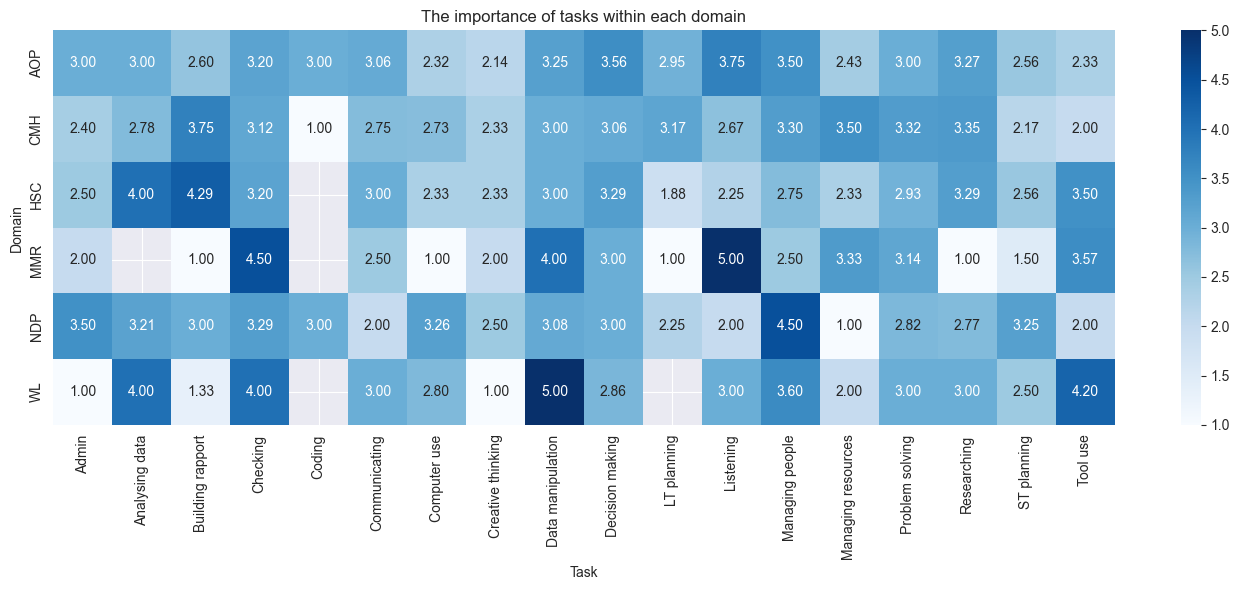

In [15]:
# heatmap
def plot_heatmap(title,value_label="weighted_score"):
    task_summary = create_task_summary(df_tasks,["task","domain"])
    heatmap_data = task_summary.copy()
    heatmap_data["domain"] = heatmap_data["domain"].map(num2domain_acronym)
    heatmap_data = heatmap_data.pivot(index="domain", columns="task", values=value_label)
    plt.figure(figsize=(14,6))
    sns.heatmap(
        heatmap_data, annot=True, fmt=".2f", cmap="Blues"
    )
    plt.title(title)
    plt.xlabel("Task")
    plt.ylabel("Domain")
    plt.tight_layout()
    plt.show()

title = f"The importance of tasks within each domain"
plot_heatmap(title)

Question 3 also includes the number of hours per week spent on each task (Q3.3), how 'social' the task is (Q3.4), or how 'digital' (0 = completely physical, 100 = completely digital) a task is (Q3.5). The above functions can be used to repeat the same analysis for these values.

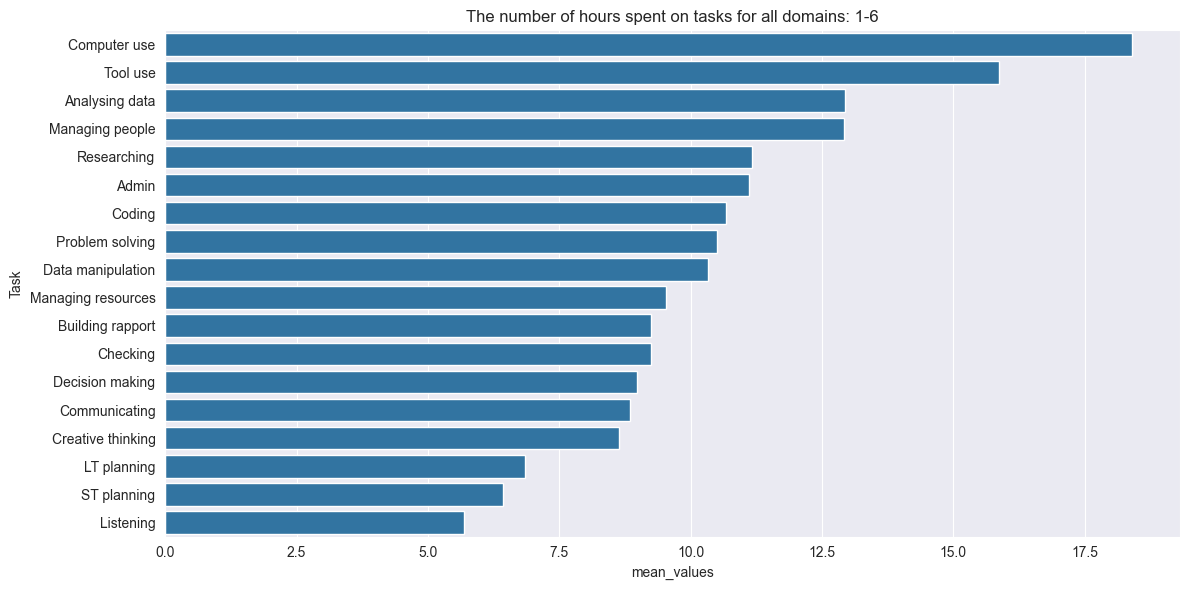

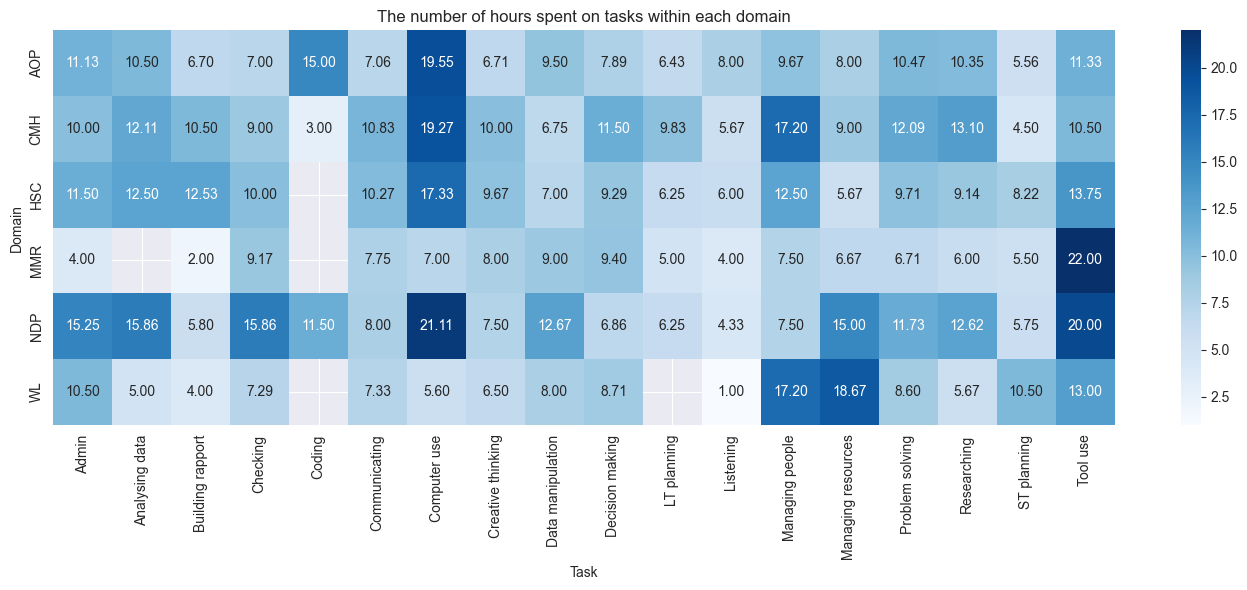

In [16]:
# hours performing task
question = "Q3.3"
df_tasks = select_task_data(question)
df_tasks["points"] = df_tasks["value"] # don't invert

bar_title = f"The number of hours spent on tasks for {num2domain_acronym[selected_domain]}: {num2domain_subtype[selected_domain]}"
plot_barplot(selected_domain,bar_title,value_label="mean_values")

heatmap_title = f"The number of hours spent on tasks within each domain"
plot_heatmap(heatmap_title,value_label="mean_values")

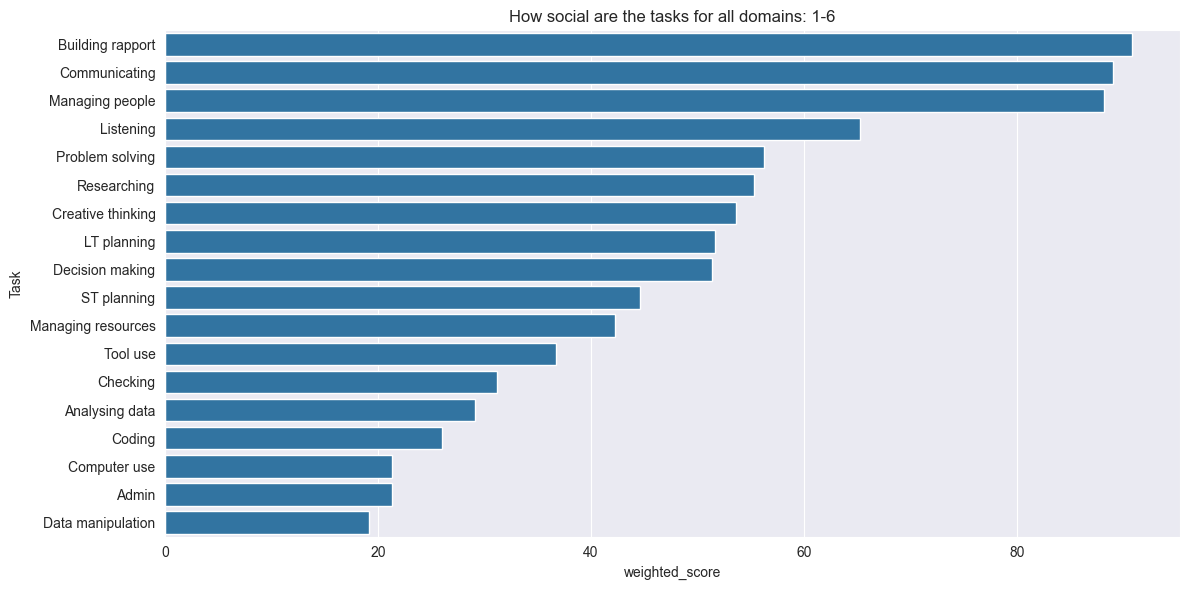

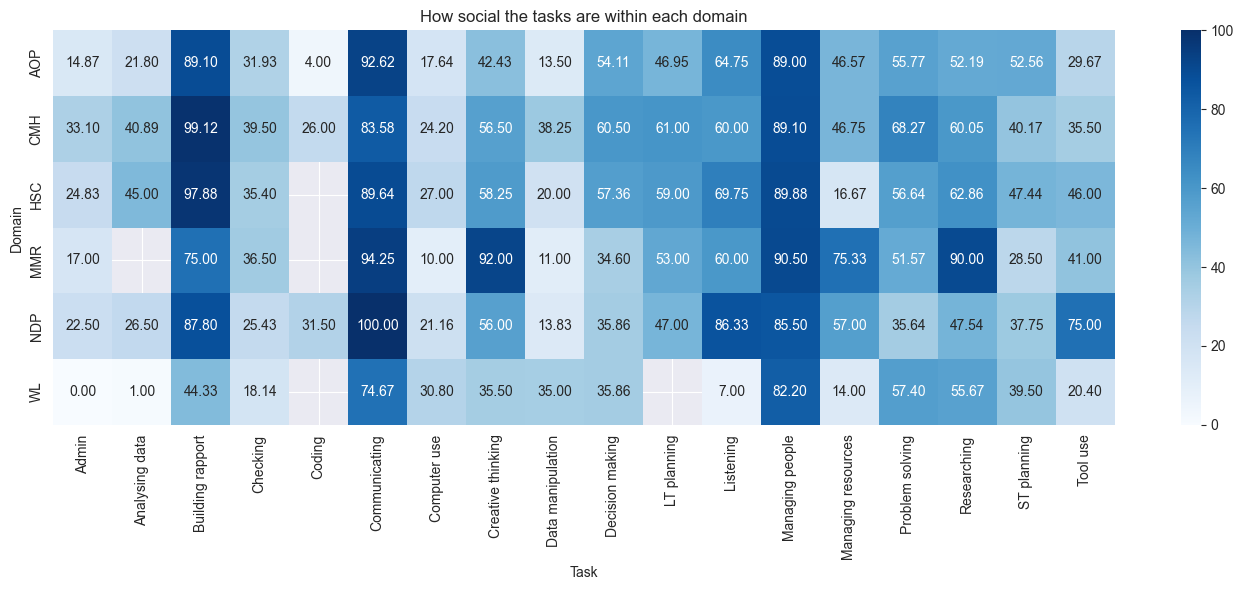

In [17]:
# how social is the task
question = "Q3.4"
df_tasks = select_task_data(question)
df_tasks["points"] = df_tasks["value"] # don't invert

bar_title = f"How social are the tasks for {num2domain_acronym[selected_domain]}: {num2domain_subtype[selected_domain]}"
plot_barplot(selected_domain,bar_title)

heatmap_title = f"How social the tasks are within each domain"
plot_heatmap(heatmap_title)

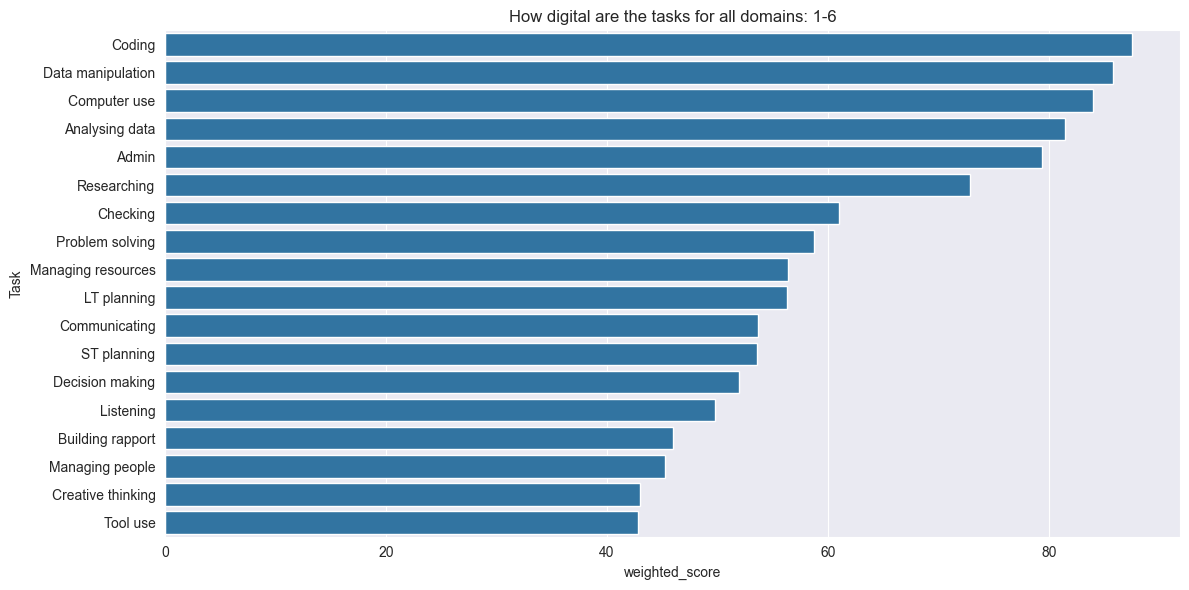

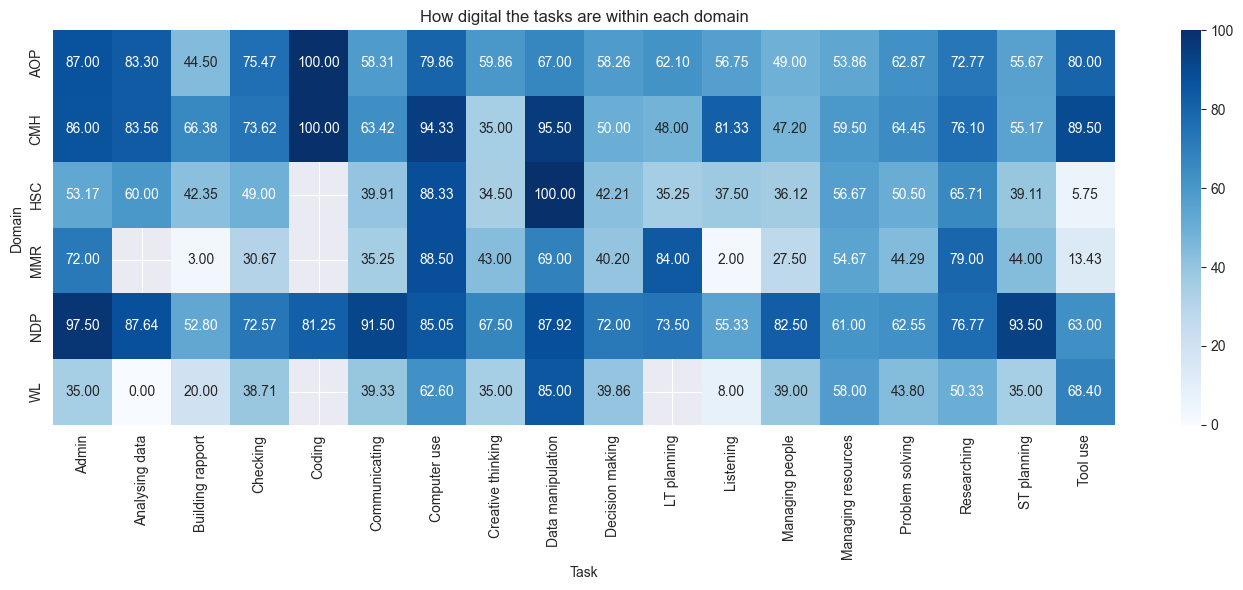

In [18]:
# how digital is the task
question = "Q3.5"
df_tasks = select_task_data(question)
df_tasks["points"] = df_tasks["value"] # don't invert

bar_title = f"How digital are the tasks for {num2domain_acronym[selected_domain]}: {num2domain_subtype[selected_domain]}"
plot_barplot(selected_domain,bar_title)

heatmap_title = f"How digital the tasks are within each domain"
plot_heatmap(heatmap_title)

Question 5 'the robot question' cycles through each of the tasks that participants' selected and asks them to distribute 100 'ability points' between the 5 most important capabilities for that task.

In [19]:
abilities

,Number,Abilities,Explanation,Acronym,Example 1,Example 2,Examples from DS
0,1,Episodic Memory,Remembering previous events,EM,Remembering the last time you visited a place,Remembering the last time you met with a client,Remembering a mistake you made on a previous p...
1,2,Semantic Memory,Remembering facts and information,SM,Recalling product descriptions or specifications,Recalling information about a customer or client,Recalling a specific formula or algorithm
2,3,Procedural Memory,Remembering how to perform learned tasks or sk...,ProcM,Remembering how to drive a car or operate a ma...,Remembering how to initiate and maintain a con...,Remembering how to type the correct syntax for...
3,4,Prospective Memory,Remembering to do what you had planned to do,ProsM,Remembering to pick up a package after work,Remembering to call a client after lunch,Remembering to fix a bug in the code a day later
4,5,Working Memory,Holding multiple pieces of information in your...,WM,Remembering the architect's plan you just revi...,Remembering the email address you were just to...,Remembering the name of the function you just ...
5,6,Attention and Inhibitory Control,Controlling behaviours or thoughts to focus on...,AaIC,Focusing on the task rather than the noise fro...,Calmly listening to a customer's grievances an...,Focusing on the current bug even though you ha...
6,7,Cognitive Flexibility,Switching between tasks or adapting to changin...,CF,Modifying your usual work process to deal with...,Sending an email whilst following the discussi...,Adjusting to different syntax after changing b...
7,8,Mental Simulation,Imagining possible future scenarios that might...,MS,Imagining what would happen if you removed the...,Imagining what would happen if you told a piec...,Imagining what would happen if you added a new...
8,9,Planning,Mapping out a strategy or a sequence of action...,P,Deciding that you need to measure and mark the...,"Deciding to first greet the host, then approac...","Deciding to first clean the dataset, then perf..."
9,10,Metacognition,"Thinking about or assessing your own thoughts,...",MC,Deciding whether that piece of furniture is to...,Deciding whether you need notes to deliver a p...,Deciding if you have enough understanding of t...


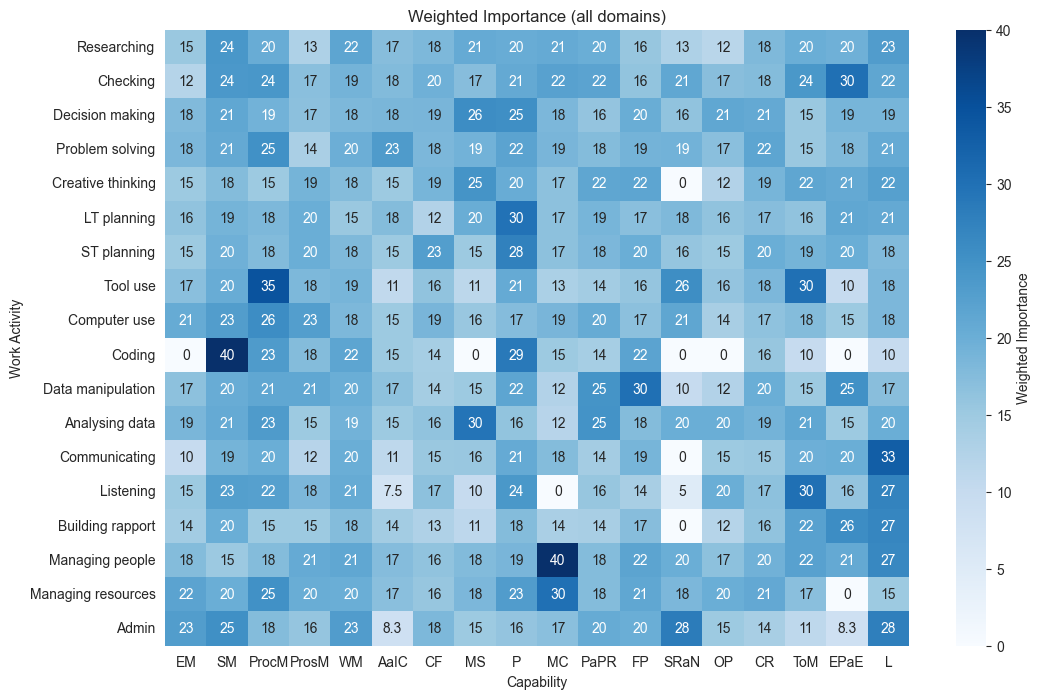

In [20]:
df_abilities = df.copy()
if selected_domain > 0:
    df_abilities = df_abilities[df_abilities["Q2.11"] == selected_domain]
df_abilities = df_abilities.loc[:, df_abilities.columns.str.contains("Q5.4")]

# convert to long format
df_abilities = df_abilities.melt(var_name="task_ability", value_name="score")
df_abilities = df_abilities.dropna(subset=["score"])
df_abilities["task"] = df_abilities["task_ability"].str.extract(r"^(\d+)_")[0].astype(int)
df_abilities["ability"] = df_abilities["task_ability"].str.extract(r"_(\d+)$")[0].astype(int)
df_abilities = df_abilities[df_abilities["task"] < 19] # drop user-generated tasks

# create summary
ability_summary = df_abilities.groupby(["task", "ability"])["score"].agg(["sum", "count"])
ability_summary["weighted_score"] = ability_summary["sum"] / ability_summary["count"]

# useful dictionaries
num2task = dict(zip(tasks["Number"],tasks["Heading"]))
num2ability = dict(zip(abilities["Number"],abilities["Acronym"]))

# reshuffle summary into a matrix
task_order = [num2task[n] for n in tasks["Number"]]
ability_order = [num2ability[n] for n in abilities["Number"]]
ability_matrix = ability_summary.copy().reset_index()
ability_matrix["task"] = pd.Categorical(
    ability_matrix["task"].map(num2task),
    categories=task_order,
    ordered=True)
ability_matrix["ability"] = pd.Categorical(
    ability_matrix["ability"].map(num2ability),
    categories=ability_order,
    ordered=True)
ability_matrix = ability_matrix.set_index(["task", "ability"])
ability_matrix = ability_matrix["weighted_score"].unstack(fill_value=0)
ability_matrix.to_csv("ability_matrix.csv")

# plot heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(ability_matrix, annot=True, cmap="Blues", cbar_kws={'label': 'Weighted Importance'})
plt.xlabel("Capability")
plt.ylabel("Work Activity")
plt.title(f"Weighted Importance ({num2domain_acronym[selected_domain]})")
plt.show()

Now let's take a look at how similar the ability matrices are between data sources (company-recruited or online participants). To do this, we'll compute separate ability matrices for each data source for the selected domain, then perform a correlation analysis.

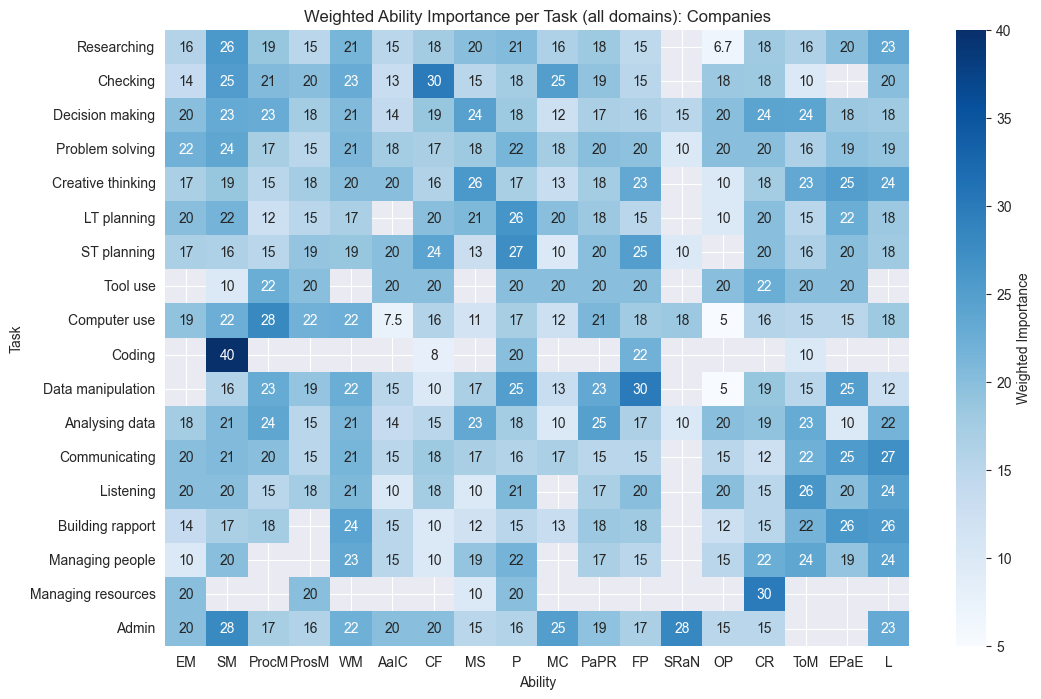

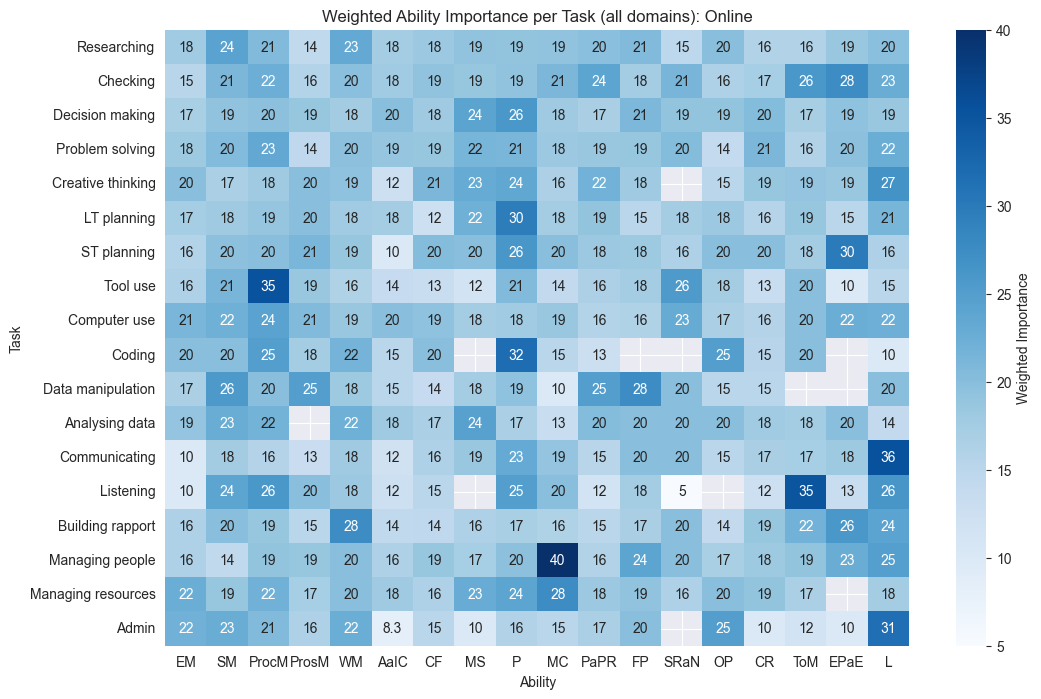

In [26]:
ability_matrices = {}
for src in df["source"].unique():
    df_src = df[df["source"] == src]
    if selected_domain > 0:
        df_src = df_src[df_src["Q2.11"] == selected_domain]
    df_abilities_src = df_src.filter(like="Q5.4")
    df_long = (
        df_abilities_src
        .melt(var_name="task_ability", value_name="score")
        .dropna(subset=["score"])
        .assign(
            task=lambda x: x["task_ability"].str.extract(r"^(\d+)_")[0].astype(int),
            ability=lambda x: x["task_ability"].str.extract(r"_(\d+)$")[0].astype(int)
        )
        .query("task < 19")
    )
    ability_summary = (
        df_long.groupby(["task", "ability"])["score"]
        .agg(["sum", "count"])
        .assign(weighted_score=lambda x: x["sum"] / x["count"])
    )
    idx = pd.MultiIndex.from_product([tasks["Number"], abilities["Number"]], names=["task", "ability"])
    ability_summary = ability_summary.reindex(idx)
    ability_matrix = (
        ability_summary.reset_index()
        .assign(
            task=lambda x: pd.Categorical(x["task"].map(num2task), categories=task_order, ordered=True),
            ability=lambda x: pd.Categorical(x["ability"].map(num2ability), categories=ability_order, ordered=True)
        )
        .set_index(["task", "ability"])["weighted_score"]
        .unstack()  # keep NaN for missing
    )
    ability_matrices[src] = ability_matrix

# plot heatmaps
src1, src2 = ability_matrices.keys()

A = ability_matrices[src1]
B = ability_matrices[src2]

plt.figure(figsize=(12, 8))
sns.heatmap(A, annot=True, cmap="Blues", cbar_kws={'label': 'Weighted Importance'})
plt.xlabel("Ability")
plt.ylabel("Task")
plt.title(f"Weighted Ability Importance per Task ({num2domain_acronym[selected_domain]}): Companies")
plt.show()

plt.figure(figsize=(12, 8))
sns.heatmap(B, annot=True, cmap="Blues", cbar_kws={'label': 'Weighted Importance'})
plt.xlabel("Ability")
plt.ylabel("Task")
plt.title(f"Weighted Ability Importance per Task ({num2domain_acronym[selected_domain]}): Online")
plt.show()

In [27]:
def cosine_similarity(x, y):
    mask = ~np.isnan(x) & ~np.isnan(y)
    if not np.any(mask):
        return np.nan
    x, y = x[mask], y[mask]
    nx, ny = norm(x), norm(y)
    return np.dot(x, y) / (nx * ny) if nx > 0 and ny > 0 else np.nan

# Columnwise (abilities)
colwise_pearson = A.corrwith(B)
colwise_cosine = [cosine_similarity(A.iloc[:, i].to_numpy(), B.iloc[:, i].to_numpy()) for i in range(A.shape[1])]
colwise_df = pd.DataFrame({
    "ability": A.columns,
    f"pearson_{src1}_vs_{src2}": colwise_pearson.values,
    f"cosine_{src1}_vs_{src2}": colwise_cosine
}).set_index("ability").reindex(A.columns)

# Rowwise (tasks)
rowwise_pearson = A.T.corrwith(B.T)
rowwise_cosine = [cosine_similarity(A.iloc[i, :].to_numpy(), B.iloc[i, :].to_numpy()) for i in range(A.shape[0])]
rowwise_df = pd.DataFrame({
    "task": A.index,
    f"pearson_{src1}_vs_{src2}": rowwise_pearson.values,
    f"cosine_{src1}_vs_{src2}": rowwise_cosine
}).set_index("task").reindex(A.index)

# Display results
display(colwise_df)
display(rowwise_df)


,pearson_companies_vs_online,cosine_companies_vs_online
ability,,
EM,0.079101,0.967020
SM,0.020043,0.953350
ProcM,0.291667,0.970654
ProsM,0.497776,0.988544
WM,0.512601,0.993739
AaIC,-0.565953,0.920966
CF,0.080073,0.946301
MS,0.496719,0.973046
P,0.471185,0.982162


,pearson_companies_vs_online,cosine_companies_vs_online
task,,
Researching,0.426369,0.978907
Checking,0.050295,0.958946
Decision making,0.134858,0.980098
Problem solving,0.110489,0.981695
Creative thinking,0.366212,0.975543
LT planning,0.299536,0.970828
ST planning,0.261780,0.961473
Tool use,-0.008125,0.937454
Computer use,0.426189,0.961281
